In [1]:
# Switch to gpu
import tensorflow as tf
device_name=tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

SystemError: GPU device not found

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Indian Food Dataset - Exploratory Data Analysis
# ================================================

# Install required packages
!pip install roboflow opencv-python matplotlib seaborn pandas numpy plotly
!pip install -U ultralytics


# Import libraries
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from roboflow import Roboflow
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# ================================================
# 1. DOWNLOAD DATASET FROM ROBOFLOW
# ================================================

# Roboflow credentials
ROBOFLOW_API_KEY = "gBNFxoMu6OxME3XcrbM3"
ROBOFLOW_WORKSPACE_ID = "foodify"
ROBOFLOW_PROJECT_ID = "indianfoodnet-qkfm2"
ROBOFLOW_VERSION_ID =3

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE_ID).project(ROBOFLOW_PROJECT_ID)
dataset = project.version(ROBOFLOW_VERSION_ID).download("yolov12")

print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to IndianFoodNet-6 in yolov11:: 100%|██████████| 10904/10904 [00:02<00:00, 4012.84it/s]


Dataset downloaded to: /content/IndianFoodNet-6


In [ ]:
# ================================================
# 2. PARSE DATASET INFORMATION
# ================================================

def parse_yolo_annotations(dataset_path, split='train'):
    """Parse YOLO format annotations"""
    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')

    data = []

    if not os.path.exists(images_path) or not os.path.exists(labels_path):
        print(f"Warning: {split} split not found")
        return pd.DataFrame()

    for img_file in os.listdir(images_path):
        if img_file.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(images_path, img_file)
            label_file = os.path.splitext(img_file)[0] + '.txt'
            label_path = os.path.join(labels_path, label_file)

            # Get image dimensions
            img = cv2.imread(img_path)
            if img is None:
                continue
            img_height, img_width = img.shape[:2]

            # Parse annotations
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            x_center = float(parts[1])
                            y_center = float(parts[2])
                            width = float(parts[3])
                            height = float(parts[4])

                            # Convert to absolute coordinates
                            bbox_width = width * img_width
                            bbox_height = height * img_height
                            bbox_area = bbox_width * bbox_height
                            bbox_aspect_ratio = bbox_width / bbox_height if bbox_height > 0 else 0

                            data.append({
                                'image': img_file,
                                'split': split,
                                'class_id': class_id,
                                'img_width': img_width,
                                'img_height': img_height,
                                'img_area': img_width * img_height,
                                'x_center': x_center,
                                'y_center': y_center,
                                'bbox_width_norm': width,
                                'bbox_height_norm': height,
                                'bbox_width': bbox_width,
                                'bbox_height': bbox_height,
                                'bbox_area': bbox_area,
                                'bbox_aspect_ratio': bbox_aspect_ratio
                            })

    return pd.DataFrame(data)

# Load class names
data_yaml_path = os.path.join(dataset.location, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    import yaml
    data_config = yaml.safe_load(f)
    class_names = data_config['names']

print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

# Parse all splits
train_df = parse_yolo_annotations(dataset.location, 'train')
valid_df = parse_yolo_annotations(dataset.location, 'valid')
test_df = parse_yolo_annotations(dataset.location, 'test')

# Combine all data
all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

# Add class names
all_df['class_name'] = all_df['class_id'].map(lambda x: class_names[x] if x < len(class_names) else f'Class_{x}')
train_df['class_name'] = train_df['class_id'].map(lambda x: class_names[x] if x < len(class_names) else f'Class_{x}')

print(f"\nDataset Summary:")
print(f"Total images (unique): {all_df['image'].nunique()}")
print(f"Total annotations: {len(all_df)}")
print(f"Train annotations: {len(train_df)}")
print(f"Valid annotations: {len(valid_df)}")
print(f"Test annotations: {len(test_df)}")


Number of classes: 30
Classes: ['AlooGobi', 'AlooMasala', 'Bhatura', 'BhindiMasala', 'Biryani', 'Chai', 'Chole', 'CoconutChutney', 'Dal', 'Dosa', 'DumAloo', 'FishCurry', 'Ghevar', 'GreenChutney', 'GulabJamun', 'Idli', 'Jalebi', 'Kebab', 'Kheer', 'Kulfi', 'Lassi', 'MuttonCurry', 'OnionPakoda', 'PalakPaneer', 'Poha', 'RajmaCurry', 'RasMalai', 'Samosa', 'ShahiPaneer', 'WhiteRice']

Dataset Summary:
Total images (unique): 5446
Total annotations: 8533
Train annotations: 5976
Valid annotations: 1654
Test annotations: 903


In [ ]:
# ================================================
# 12. UNDERSAMPLING OVERREPRESENTED CLASSES
# ================================================

print("\n" + "="*50)
print("UNDERSAMPLING OVERREPRESENTED CLASSES")
print("="*50)

# Define the threshold for undersampling
UNDERSAMPLE_THRESHOLD = 300

# Initialize an empty DataFrame to store the undersampled data
train_df_undersampled = pd.DataFrame()

# Iterate through each class in the training data
for class_name in train_df['class_name'].unique():
    class_data = train_df[train_df['class_name'] == class_name]
    num_instances = len(class_data)

    if num_instances > UNDERSAMPLE_THRESHOLD:
        # Undersample if the number of instances is above the threshold
        undersampled_class_data = class_data.sample(n=UNDERSAMPLE_THRESHOLD, random_state=42) # Using random_state for reproducibility
        train_df_undersampled = pd.concat([train_df_undersampled, undersampled_class_data], ignore_index=True)
        print(f"Undersampled class '{class_name}': Reduced from {num_instances} to {UNDERSAMPLE_THRESHOLD} instances.")
    else:
        # Keep all instances if below or at the threshold
        train_df_undersampled = pd.concat([train_df_undersampled, class_data], ignore_index=True)
        print(f"Kept all instances for class '{class_name}': {num_instances} instances.")

# Update train_df with the undersampled data
train_df = train_df_undersampled

print(f"\nUndersampling complete. New number of training annotations: {len(train_df)}")

# Verify the new class distribution in the training set
print("\nNew Class Distribution in Training Set:")
print(train_df['class_name'].value_counts())

# Re-calculate and print the imbalance ratio for the undersampled training data
class_counts_undersampled = train_df['class_name'].value_counts()
max_count_undersampled = class_counts_undersampled.max()
min_count_undersampled = class_counts_undersampled.min()
imbalance_ratio_undersampled = max_count_undersampled / min_count_undersampled if min_count_undersampled > 0 else float('inf')

print(f"\nNew Imbalance Ratio (Undersampled Training Data): {imbalance_ratio_undersampled:.2f}:1")

# Optional: Re-run the class distribution analysis visualization with the new train_df
# This requires re-combining with valid_df and test_df if you want to see the overall impact
# For now, just showing the counts for the undersampled training data.


UNDERSAMPLING OVERREPRESENTED CLASSES
Kept all instances for class 'FishCurry': 157 instances.
Kept all instances for class 'Lassi': 213 instances.
Kept all instances for class 'RasMalai': 151 instances.
Kept all instances for class 'Chole': 268 instances.
Kept all instances for class 'GreenChutney': 197 instances.
Kept all instances for class 'Ghevar': 189 instances.
Kept all instances for class 'Biryani': 158 instances.
Undersampled class 'Kebab': Reduced from 358 to 300 instances.
Kept all instances for class 'Chai': 203 instances.
Kept all instances for class 'Poha': 132 instances.
Kept all instances for class 'AlooGobi': 132 instances.
Kept all instances for class 'RajmaCurry': 140 instances.
Kept all instances for class 'WhiteRice': 199 instances.
Kept all instances for class 'OnionPakoda': 143 instances.
Kept all instances for class 'ShahiPaneer': 142 instances.
Undersampled class 'Bhatura': Reduced from 321 to 300 instances.
Undersampled class 'Idli': Reduced from 303 to 300 i


CLASS DISTRIBUTION ANALYSIS

Class Distribution:
class_name
Kebab             300
Bhatura           300
Idli              300
GulabJamun        300
Chole             268
Kulfi             263
Samosa            242
Lassi             213
CoconutChutney    206
Chai              203
Dosa              202
WhiteRice         199
GreenChutney      197
Ghevar            189
Kheer             179
PalakPaneer       161
Biryani           158
BhindiMasala      157
FishCurry         157
DumAloo           153
Dal               152
RasMalai          151
Jalebi            146
MuttonCurry       146
OnionPakoda       143
ShahiPaneer       142
AlooMasala        141
RajmaCurry        140
AlooGobi          132
Poha              132
Name: count, dtype: int64

Class Distribution by Split:
split           train
class_name           
AlooGobi          132
AlooMasala        141
Bhatura           300
BhindiMasala      157
Biryani           158
Chai              203
Chole             268
CoconutChutney    206
Dal

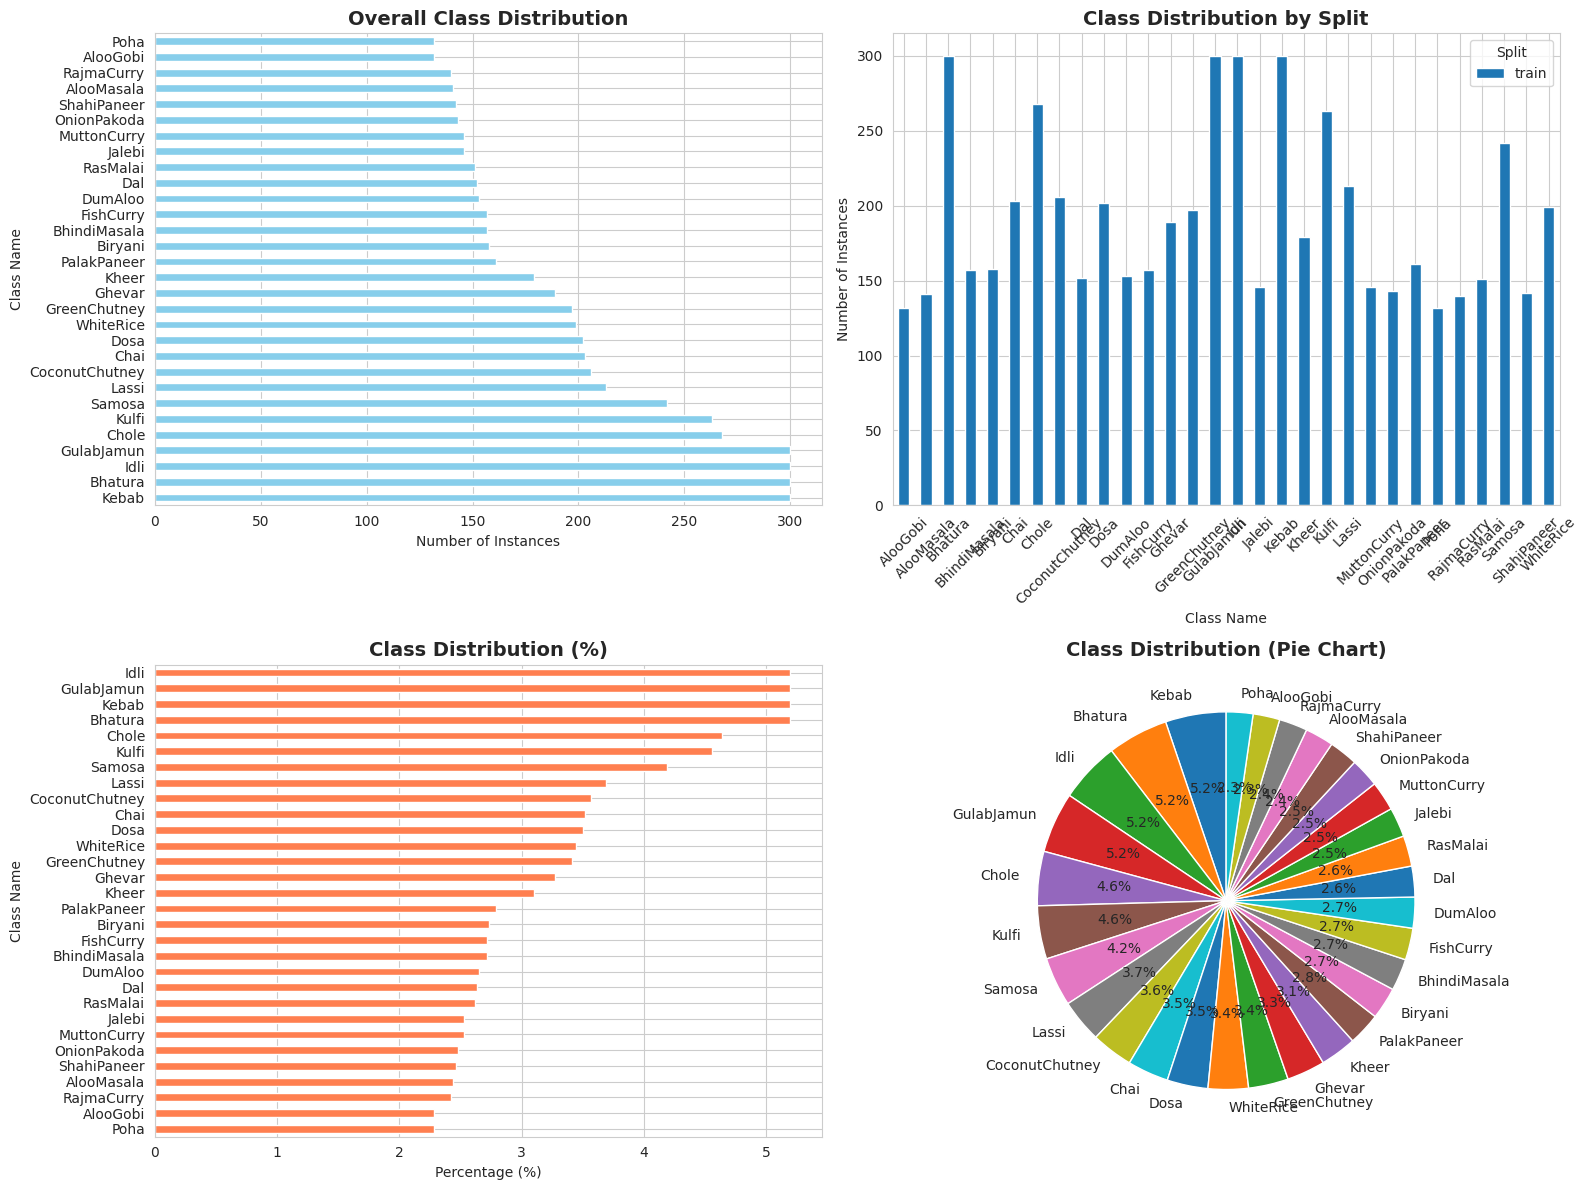

In [ ]:
# ================================================
# 3. CLASS DISTRIBUTION ANALYSIS
# ================================================

print("\n" + "="*50)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*50)

# Overall class distribution
class_counts = train_df['class_name'].value_counts()
print("\nClass Distribution:")
print(class_counts)

# Class distribution by split
class_split_counts = pd.crosstab(train_df['class_name'], all_df['split'])
print("\nClass Distribution by Split:")
print(class_split_counts)

# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall distribution
ax1 = axes[0, 0]
class_counts.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Instances')
ax1.set_ylabel('Class Name')

# Distribution by split
ax2 = axes[0, 1]
class_split_counts.plot(kind='bar', ax=ax2, stacked=False)
ax2.set_title('Class Distribution by Split', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class Name')
ax2.set_ylabel('Number of Instances')
ax2.legend(title='Split')
ax2.tick_params(axis='x', rotation=45)

# Percentage distribution
ax3 = axes[1, 0]
class_pct = (class_counts / class_counts.sum() * 100).sort_values(ascending=True)
class_pct.plot(kind='barh', ax=ax3, color='coral')
ax3.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Percentage (%)')
ax3.set_ylabel('Class Name')

# Pie chart
ax4 = axes[1, 1]
ax4.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
ax4.set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



CLASS IMBALANCE ANALYSIS

Imbalance Metrics:
Most common class: Kebab (300 instances)
Least common class: AlooGobi (132 instances)
Imbalance Ratio: 2.27:1
Mean instances per class: 192.40
Std instances per class: 56.35

Recommended Class Weights (for training):
AlooGobi: 0.641
AlooMasala: 0.641
Bhatura: 0.641
BhindiMasala: 0.641
Biryani: 0.718
Chai: 0.732
Chole: 0.795
CoconutChutney: 0.903
Dal: 0.934
Dosa: 0.948
DumAloo: 0.952
FishCurry: 0.967
Ghevar: 0.977
GreenChutney: 1.018
GulabJamun: 1.075
Idli: 1.195
Jalebi: 1.218
Kebab: 1.225
Kheer: 1.225
Kulfi: 1.258
Lassi: 1.266
MuttonCurry: 1.274
OnionPakoda: 1.318
PalakPaneer: 1.318
Poha: 1.345
RajmaCurry: 1.355
RasMalai: 1.365
Samosa: 1.374
ShahiPaneer: 1.458
WhiteRice: 1.458


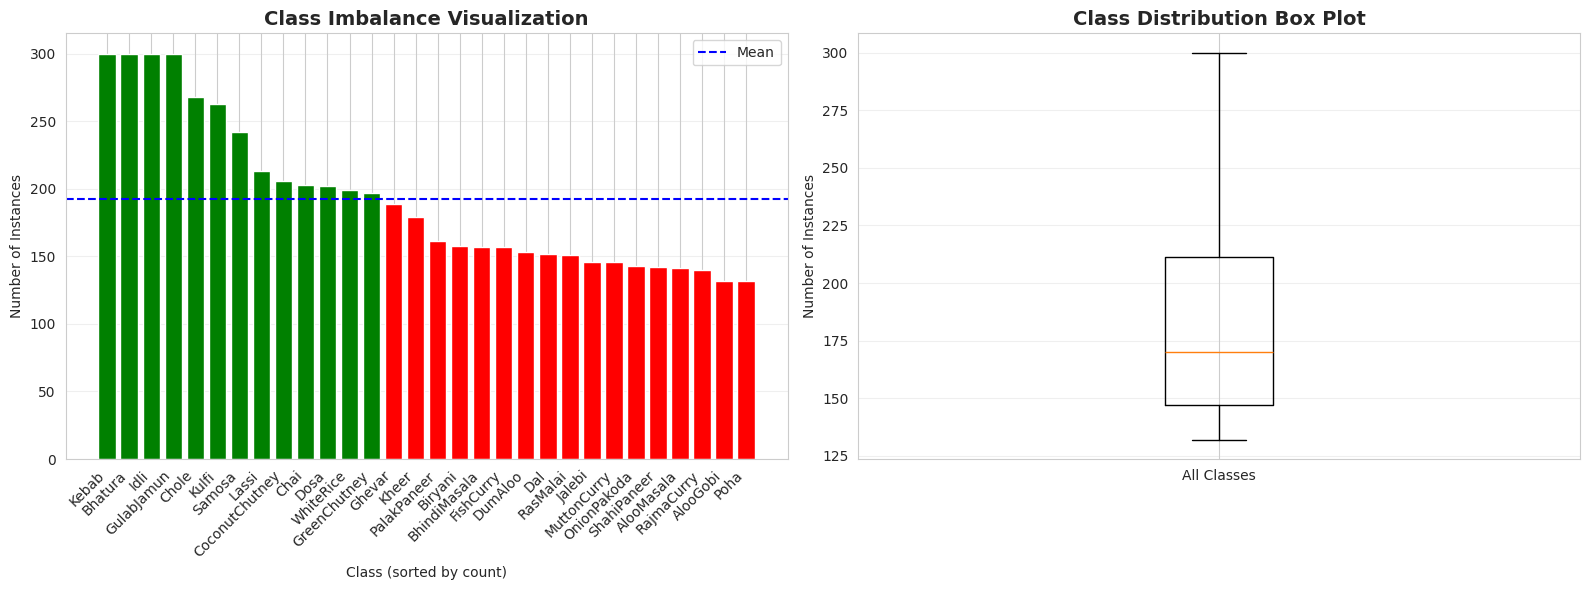

In [ ]:
# ================================================
# 4. CLASS IMBALANCE ANALYSIS
# ================================================

print("\n" + "="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)

# Calculate imbalance metrics
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nImbalance Metrics:")
print(f"Most common class: {class_counts.idxmax()} ({max_count} instances)")
print(f"Least common class: {class_counts.idxmin()} ({min_count} instances)")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Mean instances per class: {class_counts.mean():.2f}")
print(f"Std instances per class: {class_counts.std():.2f}")

# Calculate class weights for balancing
total_samples = class_counts.sum()
n_classes = len(class_counts)
class_weights = {i: total_samples / (n_classes * count)
                 for i, count in enumerate(class_counts)}

print(f"\nRecommended Class Weights (for training):")
for class_id, weight in class_weights.items():
    print(f"{class_names[class_id]}: {weight:.3f}")

# Visualize imbalance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sorted bar chart
ax1 = axes[0]
class_counts_sorted = class_counts.sort_values(ascending=False)
colors = ['red' if x < class_counts.mean() else 'green' for x in class_counts_sorted.values]
ax1.bar(range(len(class_counts_sorted)), class_counts_sorted.values, color=colors)
ax1.axhline(y=class_counts.mean(), color='blue', linestyle='--', label='Mean')
ax1.set_title('Class Imbalance Visualization', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class (sorted by count)')
ax1.set_ylabel('Number of Instances')
ax1.set_xticks(range(len(class_counts_sorted)))
ax1.set_xticklabels(class_counts_sorted.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[1]
ax2.boxplot([class_counts.values], vert=True)
ax2.set_title('Class Distribution Box Plot', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Instances')
ax2.set_xticklabels(['All Classes'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()


IMAGE STATISTICS

Image Dimensions Statistics:
       img_width  img_height  img_area
count     5446.0      5446.0    5446.0
mean       640.0       640.0  409600.0
std          0.0         0.0       0.0
min        640.0       640.0  409600.0
25%        640.0       640.0  409600.0
50%        640.0       640.0  409600.0
75%        640.0       640.0  409600.0
max        640.0       640.0  409600.0

Objects per Image Statistics:
count    5446.000000
mean        1.566838
std         1.499628
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        27.000000
Name: num_objects, dtype: float64


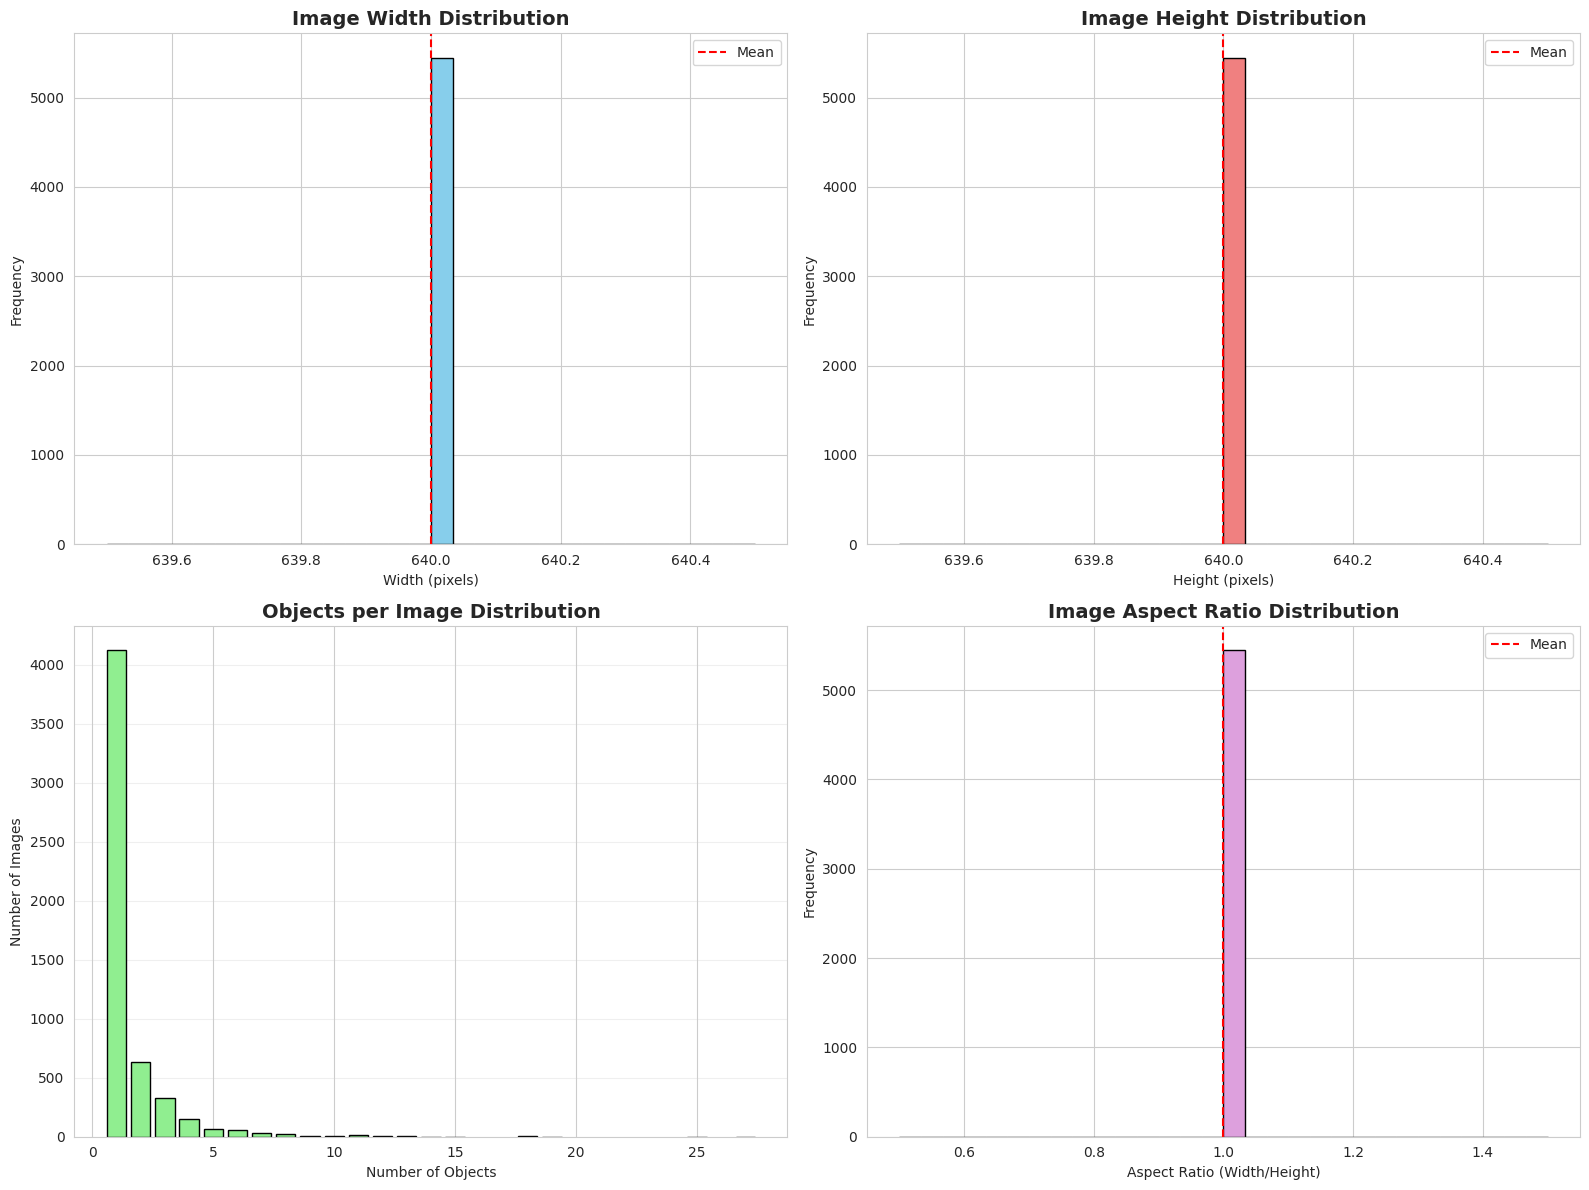

In [ ]:

# ================================================
# 5. IMAGE STATISTICS
# ================================================

print("\n" + "="*50)
print("IMAGE STATISTICS")
print("="*50)

# Get unique images
img_stats = all_df.groupby('image').agg({
    'img_width': 'first',
    'img_height': 'first',
    'img_area': 'first',
    'class_id': 'count'
}).rename(columns={'class_id': 'num_objects'})

print(f"\nImage Dimensions Statistics:")
print(img_stats[['img_width', 'img_height', 'img_area']].describe())

print(f"\nObjects per Image Statistics:")
print(img_stats['num_objects'].describe())

# Visualize image statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Image width distribution
ax1 = axes[0, 0]
ax1.hist(img_stats['img_width'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Image Width Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')
ax1.axvline(img_stats['img_width'].mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

# Image height distribution
ax2 = axes[0, 1]
ax2.hist(img_stats['img_height'], bins=30, color='lightcoral', edgecolor='black')
ax2.set_title('Image Height Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')
ax2.axvline(img_stats['img_height'].mean(), color='red', linestyle='--', label='Mean')
ax2.legend()

# Objects per image
ax3 = axes[1, 0]
objects_count = img_stats['num_objects'].value_counts().sort_index()
ax3.bar(objects_count.index, objects_count.values, color='lightgreen', edgecolor='black')
ax3.set_title('Objects per Image Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Objects')
ax3.set_ylabel('Number of Images')
ax3.grid(axis='y', alpha=0.3)

# Image aspect ratio
ax4 = axes[1, 1]
img_stats['aspect_ratio'] = img_stats['img_width'] / img_stats['img_height']
ax4.hist(img_stats['aspect_ratio'], bins=30, color='plum', edgecolor='black')
ax4.set_title('Image Aspect Ratio Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Aspect Ratio (Width/Height)')
ax4.set_ylabel('Frequency')
ax4.axvline(img_stats['aspect_ratio'].mean(), color='red', linestyle='--', label='Mean')
ax4.legend()

plt.tight_layout()
plt.savefig('image_statistics.png', dpi=300, bbox_inches='tight')
plt.show()


OUTLIER DETECTION

bbox_width:
  Outliers: 0 (0.00%)
  Lower bound: -234.00
  Upper bound: 958.00

bbox_height:
  Outliers: 0 (0.00%)
  Lower bound: -218.50
  Upper bound: 929.50

bbox_area:
  Outliers: 0 (0.00%)
  Lower bound: -239698.12
  Upper bound: 520936.88

bbox_aspect_ratio:
  Outliers: 453 (5.31%)
  Lower bound: -0.01
  Upper bound: 2.14


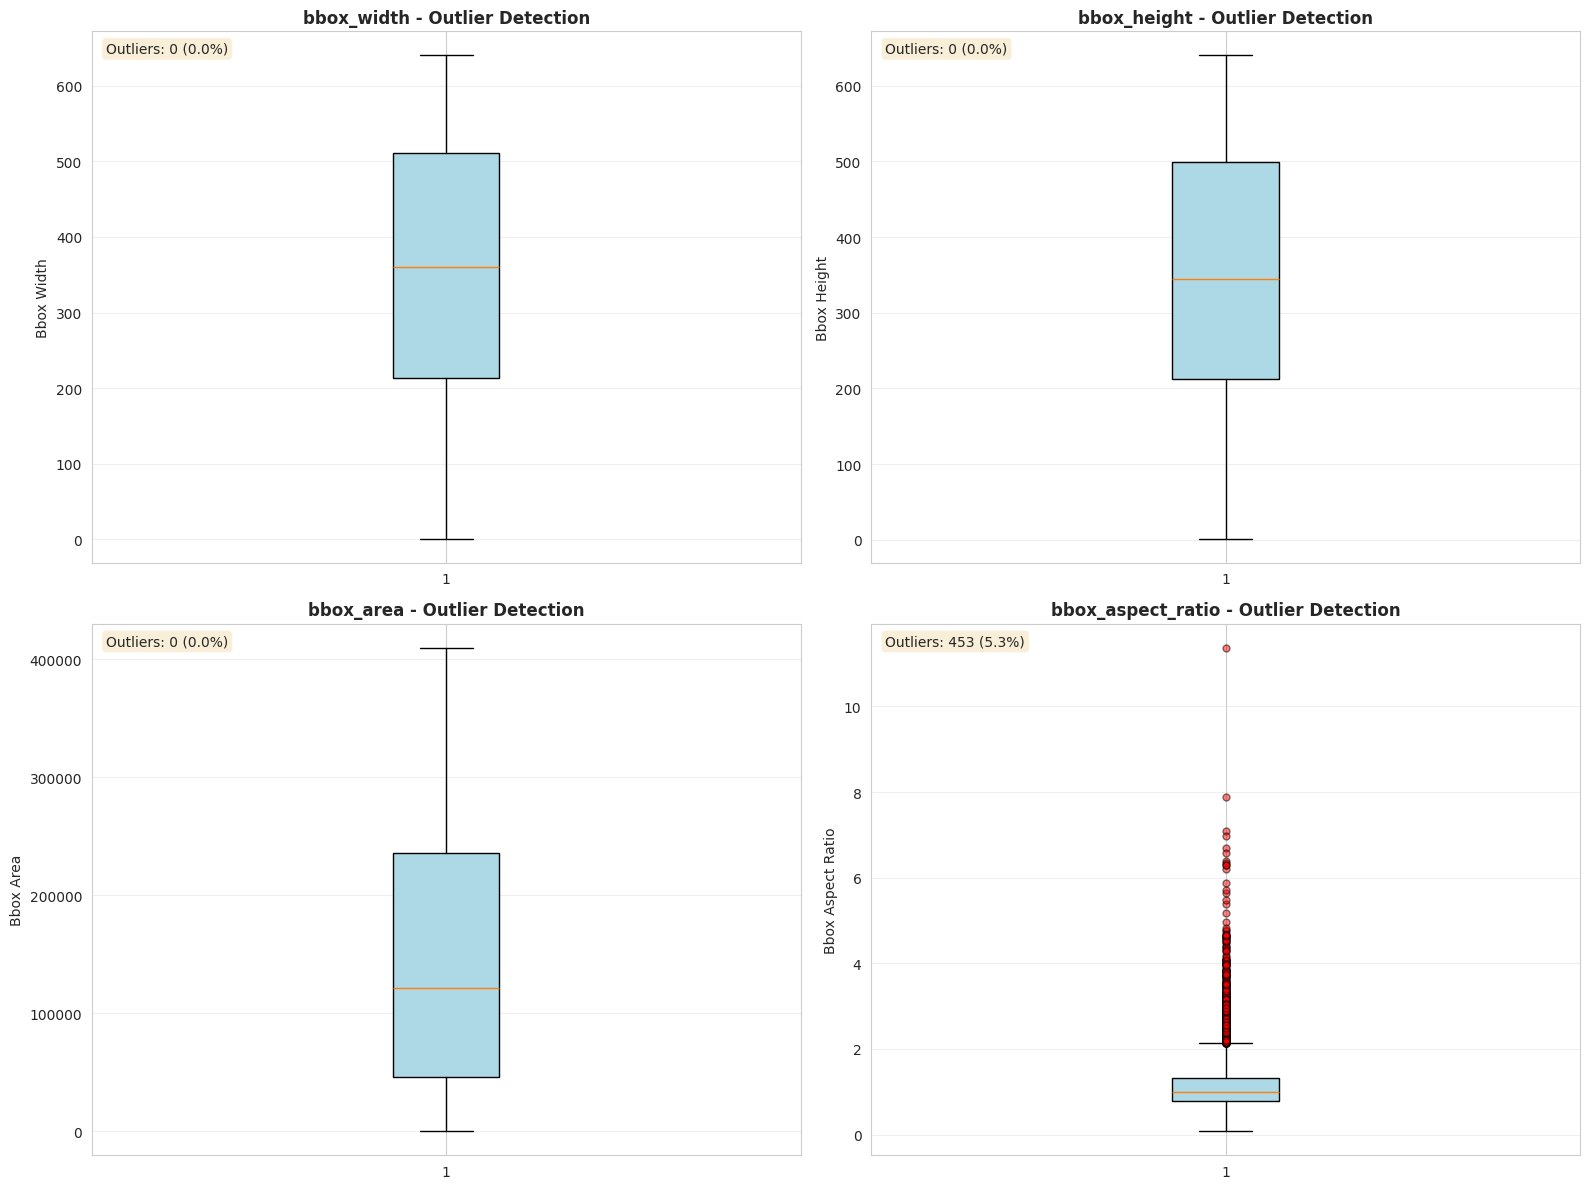


Images with extreme outliers (bbox_area):
Empty DataFrame
Columns: [image, class_name, bbox_area, bbox_width, bbox_height]
Index: []


In [ ]:
# ================================================
# 7. OUTLIER DETECTION
# ================================================

print("\n" + "="*50)
print("OUTLIER DETECTION")
print("="*50)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect outliers in various metrics
outlier_metrics = ['bbox_width', 'bbox_height', 'bbox_area', 'bbox_aspect_ratio']
outlier_results = {}

for metric in outlier_metrics:
    outliers, lower, upper = detect_outliers_iqr(all_df, metric)
    outlier_results[metric] = {
        'count': len(outliers),
        'percentage': len(outliers) / len(all_df) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }
    print(f"\n{metric}:")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(all_df)*100:.2f}%)")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")

# Visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, metric in enumerate(outlier_metrics):
    ax = axes[idx // 2, idx % 2]

    # Box plot with outliers
    bp = ax.boxplot([all_df[metric]], vert=True, patch_artist=True,
                     showfliers=True, flierprops=dict(marker='o', markerfacecolor='red',
                                                      markersize=5, alpha=0.5))
    bp['boxes'][0].set_facecolor('lightblue')

    ax.set_title(f'{metric} - Outlier Detection', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)

    # Add statistics text
    stats_text = f"Outliers: {outlier_results[metric]['count']} ({outlier_results[metric]['percentage']:.1f}%)"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# Find images with extreme outliers
print("\nImages with extreme outliers (bbox_area):")
area_outliers, _, _ = detect_outliers_iqr(all_df, 'bbox_area')
extreme_images = area_outliers.nlargest(10, 'bbox_area')[['image', 'class_name', 'bbox_area', 'bbox_width', 'bbox_height']]
print(extreme_images)


BOUNDING BOX ANALYSIS

Bounding Box Statistics:
        bbox_width  bbox_height      bbox_area  bbox_aspect_ratio
count  8533.000000  8533.000000    8533.000000        8533.000000
mean    363.714286   355.921540  150393.961209           1.143682
std     170.738327   170.581137  118244.760530           0.613657
min       1.000000     1.500000       1.500000           0.079805
25%     213.000000   212.000000   45540.000000           0.794721
50%     360.000000   344.500000  121243.000000           1.000000
75%     511.000000   499.000000  235698.750000           1.331558
max     640.000000   640.000000  409600.000000          11.363636


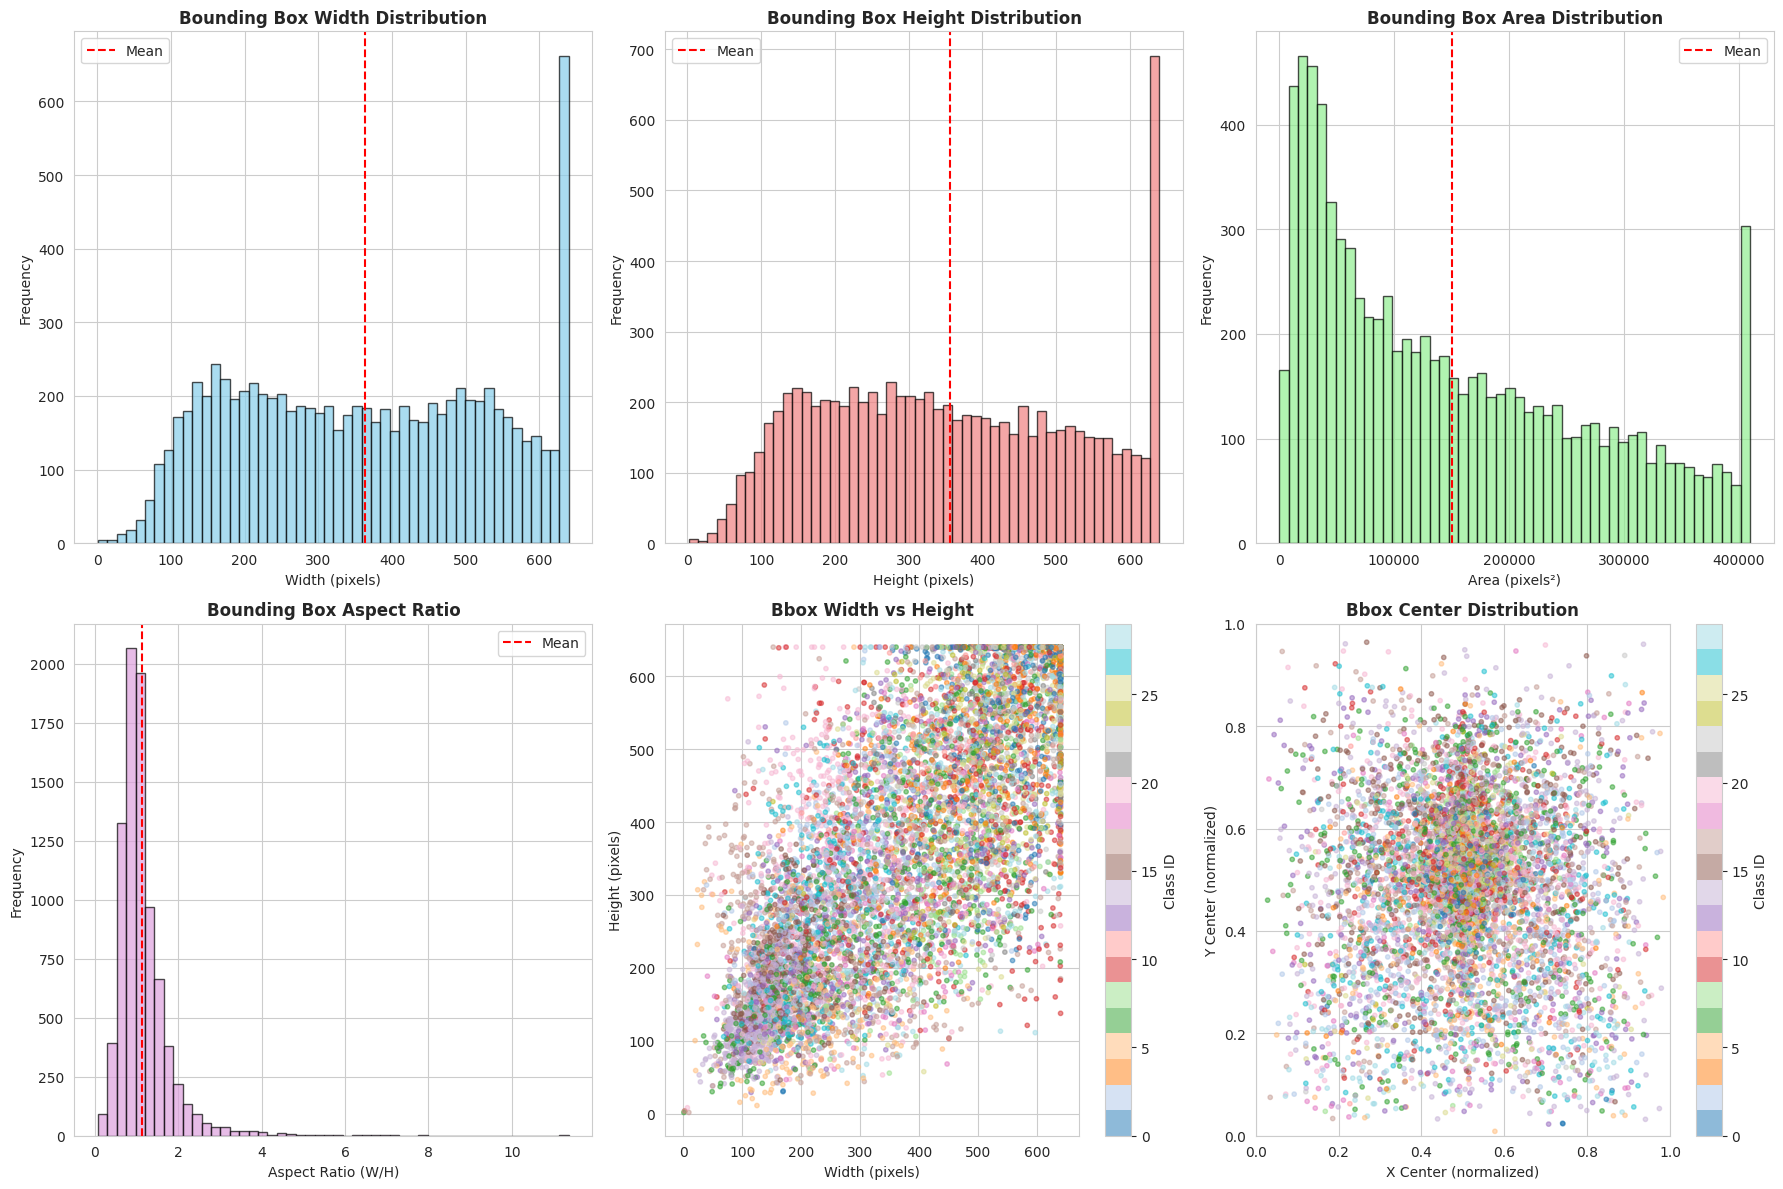


Bounding Box Statistics by Class:
                bbox_width  bbox_height      bbox_area
class_name                                            
AlooMasala      540.567500   540.947500  301004.415000
OnionPakoda     531.846341   532.717073  290925.530488
Jalebi          508.926887   492.547170  262846.997642
Poha            517.468085   493.220745  261331.179521
AlooGobi        526.051813   486.329016  260483.215026
BhindiMasala    507.984581   493.242291  258829.952643
Biryani         493.469163   484.425110  250548.715859
MuttonCurry     497.740385   486.927885  245759.168269
RajmaCurry      502.559113   469.879310  243833.477833
FishCurry       482.020362   488.076923  241572.471719
DumAloo         504.694064   459.280822  239070.630137
RasMalai        476.693548   432.260369  222895.404378
ShahiPaneer     475.467822   445.809406  218154.321782
PalakPaneer     472.371179   427.229258  206948.339520
Dal             458.316514   391.827982  184616.597477
Dosa            417.627451   3

In [ ]:
#================================================
# 6. BOUNDING BOX ANALYSIS
# ================================================

print("\n" + "="*50)
print("BOUNDING BOX ANALYSIS")
print("="*50)

print(f"\nBounding Box Statistics:")
print(all_df[['bbox_width', 'bbox_height', 'bbox_area', 'bbox_aspect_ratio']].describe())

# Visualize bounding box statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Bbox width distribution
ax1 = axes[0, 0]
ax1.hist(all_df['bbox_width'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Bounding Box Width Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')
ax1.axvline(all_df['bbox_width'].mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

# Bbox height distribution
ax2 = axes[0, 1]
ax2.hist(all_df['bbox_height'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_title('Bounding Box Height Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')
ax2.axvline(all_df['bbox_height'].mean(), color='red', linestyle='--', label='Mean')
ax2.legend()

# Bbox area distribution
ax3 = axes[0, 2]
ax3.hist(all_df['bbox_area'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax3.set_title('Bounding Box Area Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Area (pixels²)')
ax3.set_ylabel('Frequency')
ax3.axvline(all_df['bbox_area'].mean(), color='red', linestyle='--', label='Mean')
ax3.legend()

# Bbox aspect ratio
ax4 = axes[1, 0]
ax4.hist(all_df['bbox_aspect_ratio'], bins=50, color='plum', edgecolor='black', alpha=0.7)
ax4.set_title('Bounding Box Aspect Ratio', fontsize=12, fontweight='bold')
ax4.set_xlabel('Aspect Ratio (W/H)')
ax4.set_ylabel('Frequency')
ax4.axvline(all_df['bbox_aspect_ratio'].mean(), color='red', linestyle='--', label='Mean')
ax4.legend()

# Width vs Height scatter
ax5 = axes[1, 1]
scatter = ax5.scatter(all_df['bbox_width'], all_df['bbox_height'],
                      c=all_df['class_id'], cmap='tab20', alpha=0.5, s=10)
ax5.set_title('Bbox Width vs Height', fontsize=12, fontweight='bold')
ax5.set_xlabel('Width (pixels)')
ax5.set_ylabel('Height (pixels)')
plt.colorbar(scatter, ax=ax5, label='Class ID')

# Bbox center distribution
ax6 = axes[1, 2]
scatter2 = ax6.scatter(all_df['x_center'], all_df['y_center'],
                       c=all_df['class_id'], cmap='tab20', alpha=0.5, s=10)
ax6.set_title('Bbox Center Distribution', fontsize=12, fontweight='bold')
ax6.set_xlabel('X Center (normalized)')
ax6.set_ylabel('Y Center (normalized)')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
plt.colorbar(scatter2, ax=ax6, label='Class ID')

plt.tight_layout()
plt.savefig('bbox_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Bbox statistics by class
print("\nBounding Box Statistics by Class:")
bbox_by_class = all_df.groupby('class_name')[['bbox_width', 'bbox_height', 'bbox_area']].mean()
print(bbox_by_class.sort_values('bbox_area', ascending=False))


CORRELATION ANALYSIS

Correlation Matrix:
                   img_width  img_height  img_area  bbox_width  bbox_height  \
img_width                NaN         NaN       NaN         NaN          NaN   
img_height               NaN         NaN       NaN         NaN          NaN   
img_area                 NaN         NaN       NaN         NaN          NaN   
bbox_width               NaN         NaN       NaN    1.000000     0.719068   
bbox_height              NaN         NaN       NaN    0.719068     1.000000   
bbox_area                NaN         NaN       NaN    0.897850     0.909437   
bbox_aspect_ratio        NaN         NaN       NaN    0.173835    -0.414143   

                   bbox_area  bbox_aspect_ratio  
img_width                NaN                NaN  
img_height               NaN                NaN  
img_area                 NaN                NaN  
bbox_width          0.897850           0.173835  
bbox_height         0.909437          -0.414143  
bbox_area           1.00

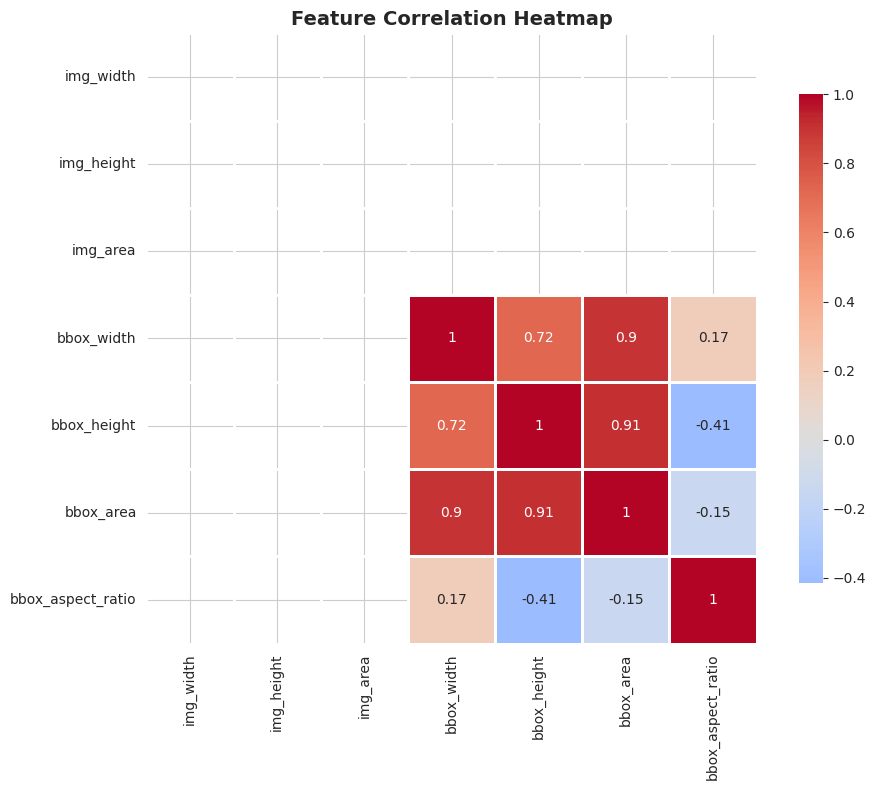

In [ ]:
# ================================================
# 8. CORRELATION ANALYSIS
# ================================================

print("\n" + "="*50)
print("CORRELATION ANALYSIS")
print("="*50)

# Select numeric columns for correlation
numeric_cols = ['img_width', 'img_height', 'img_area',
                'bbox_width', 'bbox_height', 'bbox_area', 'bbox_aspect_ratio']

correlation_matrix = all_df[numeric_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


SPLIT DISTRIBUTION ANALYSIS

Split Statistics:
       num_images  num_annotations
split                             
test          576              903
train        3797             5976
valid        1073             1654


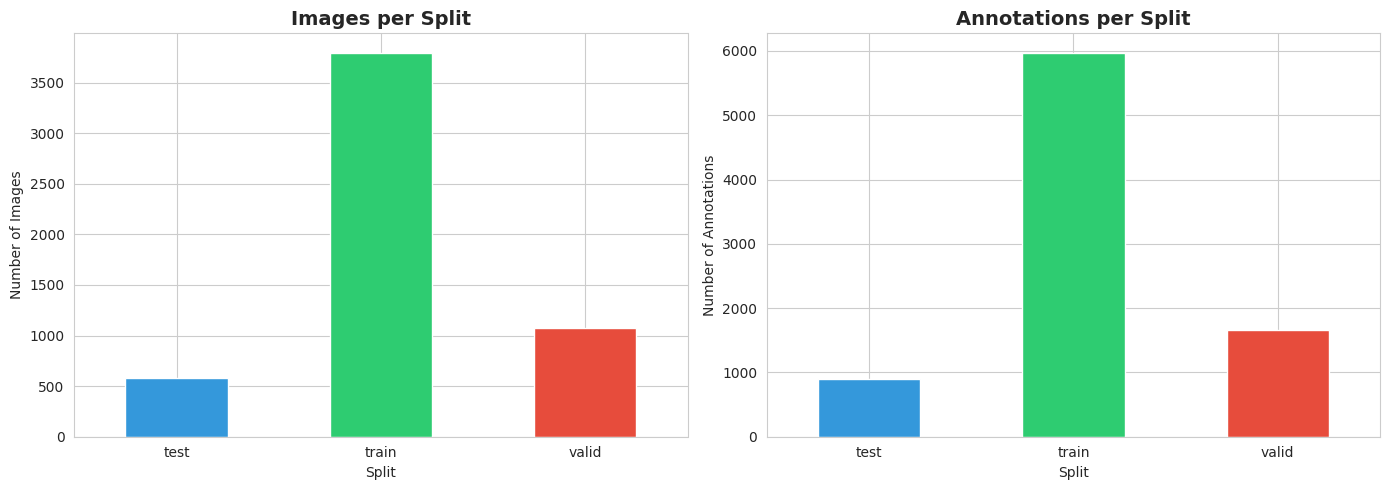

In [ ]:

# ================================================
# 9. SPLIT DISTRIBUTION ANALYSIS
# ================================================

print("\n" + "="*50)
print("SPLIT DISTRIBUTION ANALYSIS")
print("="*50)

split_stats = all_df.groupby('split').agg({
    'image': 'nunique',
    'class_id': 'count'
}).rename(columns={'image': 'num_images', 'class_id': 'num_annotations'})

print("\nSplit Statistics:")
print(split_stats)

# Visualize split distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Images per split
ax1 = axes[0]
split_stats['num_images'].plot(kind='bar', ax=ax1, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_title('Images per Split', fontsize=14, fontweight='bold')
ax1.set_xlabel('Split')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=0)

# Annotations per split
ax2 = axes[1]
split_stats['num_annotations'].plot(kind='bar', ax=ax2, color=['#3498db', '#2ecc71', '#e74c3c'])
ax2.set_title('Annotations per Split', fontsize=14, fontweight='bold')
ax2.set_xlabel('Split')
ax2.set_ylabel('Number of Annotations')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# ================================================
# 10. SUMMARY REPORT
# ================================================

print("\n" + "="*50)
print("SUMMARY REPORT")
print("="*50)

summary = f"""
INDIAN FOOD DATASET - EDA SUMMARY
{'='*60}

DATASET OVERVIEW:
- Total Classes: {len(class_names)}
- Total Images: {all_df['image'].nunique()}
- Total Annotations: {len(all_df)}

SPLIT DISTRIBUTION:
- Train: {len(train_df)} annotations, {train_df['image'].nunique()} images
- Valid: {len(valid_df)} annotations, {valid_df['image'].nunique() if len(valid_df) > 0 else 0} images
- Test: {len(test_df)} annotations, {test_df['image'].nunique() if len(test_df) > 0 else 0} images

CLASS IMBALANCE:
- Most common class: {class_counts.idxmax()} ({max_count} instances)
- Least common class: {class_counts.idxmin()} ({min_count} instances)
- Imbalance ratio: {imbalance_ratio:.2f}:1
- Recommendation: {'HIGH IMBALANCE - Use class weights or data augmentation' if imbalance_ratio > 3 else 'MODERATE IMBALANCE - Consider class weights'}

IMAGE STATISTICS:
- Avg Width: {img_stats['img_width'].mean():.0f} ± {img_stats['img_width'].std():.0f} px
- Avg Height: {img_stats['img_height'].mean():.0f} ± {img_stats['img_height'].std():.0f} px
- Avg Objects/Image: {img_stats['num_objects'].mean():.2f} ± {img_stats['num_objects'].std():.2f}

BOUNDING BOX STATISTICS:
- Avg Width: {all_df['bbox_width'].mean():.0f} ± {all_df['bbox_width'].std():.0f} px
- Avg Height: {all_df['bbox_height'].mean():.0f} ± {all_df['bbox_height'].std():.0f} px
- Avg Area: {all_df['bbox_area'].mean():.0f} ± {all_df['bbox_area'].std():.0f} px²
- Avg Aspect Ratio: {all_df['bbox_aspect_ratio'].mean():.2f} ± {all_df['bbox_aspect_ratio'].std():.2f}

OUTLIERS DETECTED:
- Bbox Width: {outlier_results['bbox_width']['count']} ({outlier_results['bbox_width']['percentage']:.1f}%)
- Bbox Height: {outlier_results['bbox_height']['count']} ({outlier_results['bbox_height']['percentage']:.1f}%)
- Bbox Area: {outlier_results['bbox_area']['count']} ({outlier_results['bbox_area']['percentage']:.1f}%)

RECOMMENDATIONS:
1. {'Address class imbalance using weighted loss or oversampling' if imbalance_ratio > 3 else 'Class distribution is acceptable'}
2. {'Consider reviewing outlier annotations for quality' if outlier_results['bbox_area']['percentage'] > 5 else 'Outliers are within acceptable range'}
3. Image sizes are {'consistent' if img_stats['img_width'].std() < 100 else 'variable'} - {'normalization recommended' if img_stats['img_width'].std() > 100 else 'current sizes acceptable'}

{'='*60}
"""

print(summary)

# Save summary to file
with open('eda_summary_report.txt', 'w') as f:
    f.write(summary)

print("\n✓ EDA Complete!")
print("✓ All visualizations saved")
print("✓ Summary report saved to 'eda_summary_report.txt'")


SUMMARY REPORT

INDIAN FOOD DATASET - EDA SUMMARY

DATASET OVERVIEW:
- Total Classes: 30
- Total Images: 5446
- Total Annotations: 8533

SPLIT DISTRIBUTION:
- Train: 5772 annotations, 3797 images
- Valid: 1654 annotations, 1073 images
- Test: 903 annotations, 576 images

CLASS IMBALANCE:
- Most common class: Kebab (300 instances)
- Least common class: AlooGobi (132 instances)
- Imbalance ratio: 2.27:1
- Recommendation: MODERATE IMBALANCE - Consider class weights

IMAGE STATISTICS:
- Avg Width: 640 ± 0 px
- Avg Height: 640 ± 0 px
- Avg Objects/Image: 1.57 ± 1.50

BOUNDING BOX STATISTICS:
- Avg Width: 364 ± 171 px
- Avg Height: 356 ± 171 px
- Avg Area: 150394 ± 118245 px²
- Avg Aspect Ratio: 1.14 ± 0.61

OUTLIERS DETECTED:
- Bbox Width: 0 (0.0%)
- Bbox Height: 0 (0.0%)
- Bbox Area: 0 (0.0%)

RECOMMENDATIONS:
1. Class distribution is acceptable
2. Outliers are within acceptable range
3. Image sizes are consistent - current sizes acceptable



✓ EDA Complete!
✓ All visualizations saved
✓ 

In [ ]:
# ================================================
# 11. INTERACTIVE VISUALIZATIONS (PLOTLY)
# ================================================

print("\nGenerating interactive visualizations...")

# Interactive class distribution
fig_interactive = go.Figure()
fig_interactive.add_trace(go.Bar(
    x=class_counts.index,
    y=class_counts.values,
    marker_color='indianred',
    text=class_counts.values,
    textposition='auto',
))
fig_interactive.update_layout(
    title='Interactive Class Distribution',
    xaxis_title='Class Name',
    yaxis_title='Number of Instances',
    height=500
)
fig_interactive.write_html('interactive_class_distribution.html')

# Interactive bbox scatter
fig_scatter = px.scatter(
    all_df,
    x='bbox_width',
    y='bbox_height',
    color='class_name',
    hover_data=['image', 'bbox_area'],
    title='Interactive Bounding Box Analysis',
    labels={'bbox_width': 'Width (px)', 'bbox_height': 'Height (px)'}
)
fig_scatter.write_html('interactive_bbox_scatter.html')

print("✓ Interactive visualizations saved as HTML files")
print("\nAll analysis complete! 🎉")


Generating interactive visualizations...
✓ Interactive visualizations saved as HTML files

All analysis complete! 🎉


In [ ]:
# ================================================
# 11. WRITE BALANCED DATASET TO DISK (NEW SECTION)
# ================================================

import shutil
print("\n" + "="*50)
print("WRITE BALANCED DATASET TO DISK")
print("="*50)

# Define paths for the new balanced dataset
original_dataset_path = dataset.location
balanced_dataset_path = os.path.join(os.path.dirname(original_dataset_path), 'IndianFoodNet-Balanced')

new_train_images_path = os.path.join(balanced_dataset_path, 'train', 'images')
new_train_labels_path = os.path.join(balanced_dataset_path, 'train', 'labels')
new_data_yaml_path = os.path.join(balanced_dataset_path, 'data_balanced.yaml')

# Create the new directories
os.makedirs(new_train_images_path, exist_ok=True)
os.makedirs(new_train_labels_path, exist_ok=True)

print(f"Created new directories at: {balanced_dataset_path}")

# Get unique images from the undersampled dataframe
# NOTE: We use the 'train_df' variable which was overwritten by the undersampled one
unique_images = train_df['image'].unique()
print(f"Total unique images in balanced train set: {len(unique_images)}")

# Copy images and write new label files
for img_file in unique_images:
    # 1. Copy the image file
    src_img_path = os.path.join(original_dataset_path, 'train', 'images', img_file)
    dst_img_path = os.path.join(new_train_images_path, img_file)
    if os.path.exists(src_img_path):
        shutil.copy(src_img_path, dst_img_path)
    else:
        print(f"Warning: Image file not found {src_img_path}")
        continue

    # 2. Get all annotations for this image from the balanced dataframe
    annotations = train_df[train_df['image'] == img_file]

    # 3. Write new label file
    label_file = os.path.splitext(img_file)[0] + '.txt'
    dst_label_path = os.path.join(new_train_labels_path, label_file)

    with open(dst_label_path, 'w') as f:
        for _, row in annotations.iterrows():
            # Write in YOLO format: class_id x_center y_center width height
            # Corrected to include y_center
            yolo_line = f"{row.class_id} {row.x_center} {row.y_center} {row.bbox_width_norm} {row.bbox_height_norm}\n"
            f.write(yolo_line)

print(f"Finished copying {len(unique_images)} images and writing new label files.")

# 4. Create new data.yaml file
# Use absolute paths to avoid issues
new_data_config = {
    'train': os.path.abspath(new_train_images_path),
    'val': os.path.abspath(os.path.join(original_dataset_path, 'valid', 'images')),
    'test': os.path.abspath(os.path.join(original_dataset_path, 'test', 'images')),
    'nc': data_config['nc'],
    'names': data_config['names']
}

with open(new_data_yaml_path, 'w') as f:
    yaml.dump(new_data_config, f, default_flow_style=False)

print(f"New data YAML file created at: {new_data_yaml_path}")


WRITE BALANCED DATASET TO DISK
Created new directories at: /content/IndianFoodNet-Balanced
Total unique images in balanced train set: 3797
Finished copying 3797 images and writing new label files.
New data YAML file created at: /content/IndianFoodNet-Balanced/data_balanced.yaml


## Image preprocessing

In [ ]:
# Image preprocessing

## YOLOv11 Model Training

In [ ]:
import yaml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import shutil

In [ ]:
from ultralytics import YOLO
import os # Import the os module

# Load a pre-trained YOLOv11 nano model for faster training
model = YOLO('yolo12n.pt')

print("\nStarting model training...")

# Train the model
# Use the path to the new, balanced data.yaml file
results = model.train(
    data=new_data_yaml_path,
    epochs=60,
    device=0,
    imgsz=640,
    name='indian_food_detector'
)
print("Training complete! Weights are saved in runs/detect/indian_food_detector/weights/best.pt")


print("\nStarting model evaluation on the validation set...")

# Run the model
metrics = model.val(
    data=new_data_yaml_path,
    split='val' # Evaluates on the validation images defined in data.yaml
)

# Print the key performance metrics
print("\n--- Final Model Performance Metrics ---")

# Access metrics using the correct keys, with a fallback
mAP50 = metrics.results_dict.get('metrics/mAP50(B)', metrics.results_dict.get('metrics/mAP50', 0.0))
mAP50_95 = metrics.results_dict.get('metrics/mAP50-95(B)', metrics.results_dict.get('metrics/mAP50-95', 0.0))
precision = metrics.results_dict.get('metrics/precision(B)', metrics.results_dict.get('metrics/precision', 0.0))
recall = metrics.results_dict.get('metrics/recall(B)', metrics.results_dict.get('metrics/recall', 0.0))


# mAP50
print(f"mAP@0.5 (Good accuracy): {mAP50: .4f}")
# mAP50-95
print(f"mAP@0.5:0.95 (Main benchmark): {mAP50_95: .4f}")
print(f"Precision: {precision: .4f}")
print(f"Recall: {recall: .4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Starting model training...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/IndianFoodNet-Balanced/data_balanced.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv

In [ ]:
# Use os.path.join to correctly construct the path
import os
best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
trained_model = YOLO(best_model_path)


In [ ]:
print("\nStarting final evaluation on the held-out TEST set (on GPU)...")

# 1. Run the model in 'val' mode.
metrics = trained_model.val(
    data=new_data_yaml_path, # Use the balanced data.yaml for consistency
    split='test',    # Uses the dedicated TEST set
    device=0   # Uses the defined GPU/CPU device
)

# Access metrics using the correct keys, with a fallback
precision = metrics.results_dict.get('metrics/precision(B)', metrics.results_dict.get('metrics/precision', 0.0))
recall = metrics.results_dict.get('metrics/recall(B)', metrics.results_dict.get('metrics/recall', 0.0))
mAP50 = metrics.results_dict.get('metrics/mAP50(B)', metrics.results_dict.get('metrics/mAP50', 0.0))
mAP50_95 = metrics.results_dict.get('metrics/mAP50-95(B)', metrics.results_dict.get('metrics/mAP50-95', 0.0))


print("--- FINAL MODEL PERFORMANCE METRICS (TEST SET) ---")

# 1. mAP@0.5 (Good Accuracy):
print(f"1. mAP@0.5 (Good Accuracy): {mAP50: .4f}")

# 2. mAP@0.5:0.95 (Main Benchmark):
print(f"2. mAP@0.5:0.95 (Main Benchmark): {mAP50_95: .4f}")

# 3. Precision:
print(f"3. Precision: {precision: .4f}")

# 4. Recall:
print(f"4. Recall: {recall: .4f}")

In [ ]:
import os
import cv2
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ====================================================================
# 1. SET YOUR IMAGE PATH
# ====================================================================
#
# 1. Upload your image to Colab (drag-and-drop or use 'Upload' button).
# 2. Right-click the uploaded file in the Colab file explorer.
# 3. Select "Copy path".
# 4. Paste the path here, replacing '/content/samosa.jpg'.
#
YOUR_IMAGE_PATH = '/content/samosa.png'

# ====================================================================
# 2. DEFINE MODEL AND DATA PATHS (FROM YOUR SCRIPT)
# ====================================================================
# This path should point to the model created by your training script
MODEL_PATH = '/content/runs/detect/indian_food_detector/weights/best.pt'

# This path points to the original YAML to get the class names
DATA_YAML_PATH = '/content/IndianFoodNet-6/data_balanced.yaml'

# ====================================================================
# 3. LOAD THE MODEL AND CLASS NAMES
# ====================================================================
print(f"Loading model from: {MODEL_PATH}")
try:
    trained_model = YOLO(MODEL_PATH)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please make sure the file exists at the correct path.")
    print("If you re-ran training, the folder might be 'indian_food_detector2' or 'indian_food_detector3'.")

print(f"Loading class names from: {DATA_YAML_PATH}")
try:
    with open(DATA_YAML_PATH, 'r') as f:
        data_config = yaml.safe_load(f)
        class_names = data_config['names']
    print(f"Loaded {len(class_names)} class names.")
except Exception as e:
    print(f"Error loading YAML file: {e}")
    print("Please make sure the 'IndianFoodNet-6' dataset folder exists.")

# ====================================================================
# 4. RUN PREDICTION
# ====================================================================
if 'trained_model' in locals() and os.path.exists(YOUR_IMAGE_PATH):
    print(f"Performing inference on: {YOUR_IMAGE_PATH}")

    # Run prediction
    # save=True will save the annotated image to a new 'runs' folder
    inference_results = trained_model.predict(
        source=YOUR_IMAGE_PATH,
        iou=0.45,
        conf=0.25,
        save=True
    )

    # ====================================================================
    # 5. DISPLAY THE RESULTS
    # ====================================================================
    annotated_image_path = None

    for r in inference_results:
        # Print detected objects and their confidences
        if hasattr(r, 'boxes') and r.boxes is not None and len(r.boxes) > 0:
            print(f"\nDetected objects in {os.path.basename(YOUR_IMAGE_PATH)}:")
            for box in r.boxes:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = class_names[class_id] if class_id < len(class_names) else f'Class_{class_id}'
                print(f"  - {class_name} (Confidence: {confidence:.2f})")
        else:
            print("No objects detected.")

        # Get the path to the saved, annotated image
        if hasattr(r, 'save_dir'):
            annotated_image_path = os.path.join(r.save_dir, os.path.basename(YOUR_IMAGE_PATH))
            print(f"\nAnnotated image saved to: {annotated_image_path}")

    # Display the annotated image
    if annotated_image_path and os.path.exists(annotated_image_path):
        try:
            img_display = cv2.imread(annotated_image_path)
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
            plt.title(f'Prediction for {os.path.basename(YOUR_IMAGE_PATH)}')
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error displaying image: {e}")
    else:
        print("Could not retrieve or find the annotated image to display.")

else:
    if 'trained_model' not in locals():
        print("Model is not loaded. Cannot run prediction.")
    if not os.path.exists(YOUR_IMAGE_PATH):
        print(f"Error: Image file not found at '{YOUR_IMAGE_PATH}'")
        print("Please check the 'YOUR_IMAGE_PATH' variable and make sure the file is uploaded.")

In [ ]:
import shutil
import os

# --- 1. DEFINE YOUR PATHS ---

# This variable 'best_model_path' should already be in your script's memory
# from the evaluation section. If not, paste the path from the training output.
# e.g., '/content/runs/detect/indian_food_detector/weights/best.pt'
source_model_path = best_model_path

# This is the path to the YAML file your script created, which has the class names.
# You NEED this for inference later.
source_yaml_path = new_data_yaml_path # Should be '/content/IndianFoodNet-Balanced/data_balanced.yaml'

# --- 2. DEFINE YOUR GOOGLE DRIVE DESTINATION ---

# This is the folder on your Drive where you'll store your model
# You can change 'My_YOLO_Models' to any name you like
drive_save_dir = "/content/drive/MyDrive/My_YOLO_Models"

# Create the full paths for the files on your Drive
drive_model_path = os.path.join(drive_save_dir, "indian_food_best.pt")
drive_yaml_path = os.path.join(drive_save_dir, "data_balanced.yaml")

# --- 3. CREATE THE DIRECTORY AND COPY FILES ---

# Create the folder on your Drive if it doesn't already exist
os.makedirs(drive_save_dir, exist_ok=True)

# Copy the model file (.pt)
try:
    shutil.copy(source_model_path, drive_model_path)
    print(f"✅ Model successfully copied to: {drive_model_path}")
except Exception as e:
    print(f"❌ Error copying model: {e}")

# Copy the data file (.yaml)
try:
    shutil.copy(source_yaml_path, drive_yaml_path)
    print(f"✅ YAML file successfully copied to: {drive_yaml_path}")
except Exception as e:
    print(f"❌ Error copying YAML: {e}")